## <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:5px 5px;">Import liabraries and load datasets</p>

In [1]:
# import data science basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load data
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:5px 5px;">Data Dictionary</p>
- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or - ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]     
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

## <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:5px 5px;">Exploratory Data Analysis</p>

In [4]:
# data shape
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
# show unique values
df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


In [7]:
# data basic statistics
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
# missing values in decerding order
df.isnull().sum().sort_values(ascending=False)

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [9]:
# duplicated values
df.duplicated().sum()

np.int64(0)

In [10]:
# numerical and categorical features
Categorical = df.select_dtypes(include=['object'])
Numerical = df.select_dtypes(include=['int64', 'float64'])
print('Categorical features:\n', Categorical)
print('Numerical features:\n', Numerical)

Categorical features:
     Sex ChestPainType RestingECG ExerciseAngina ST_Slope
0     M           ATA     Normal              N       Up
1     F           NAP     Normal              N     Flat
2     M           ATA         ST              N       Up
3     F           ASY     Normal              Y     Flat
4     M           NAP     Normal              N       Up
..   ..           ...        ...            ...      ...
913   M            TA     Normal              N     Flat
914   M           ASY     Normal              N     Flat
915   M           ASY     Normal              Y     Flat
916   F           ATA        LVH              N     Flat
917   M           NAP     Normal              N       Up

[918 rows x 5 columns]
Numerical features:
      Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease
0     40        140          289          0    172      0.0             0
1     49        160          180          0    156      1.0             1
2     37        130       

In [11]:
# count target variable
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


## <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:5px 5px;">Visualization</p>

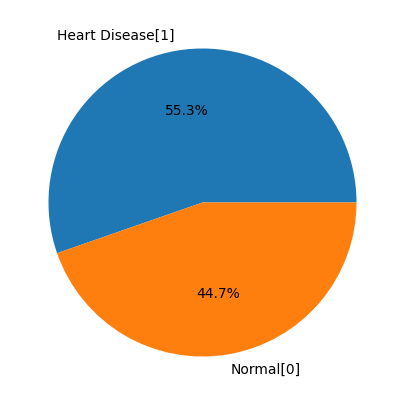

In [22]:
# Normal and Heart Disease with target column
plt.figure(figsize=(10,5))
plt.pie(df['HeartDisease'].value_counts(), labels=['Heart Disease[1]', 'Normal[0]'], autopct='%1.1f%%')
plt.show()

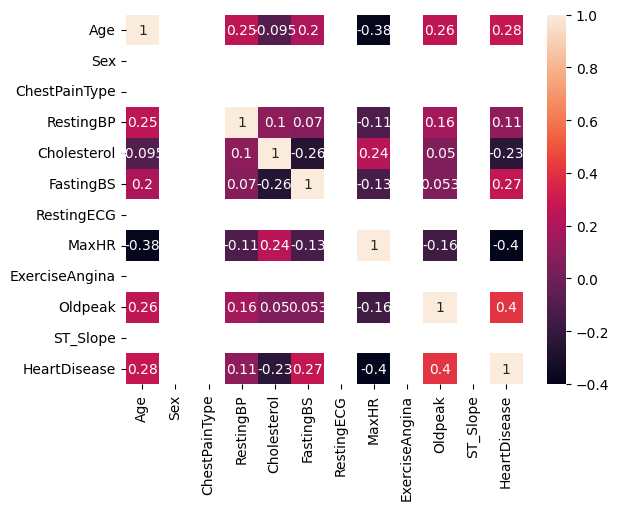

In [23]:
# ploting corelation matrix
df = pd.read_csv("heart.csv")

df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)

sns.heatmap(df.corr(), annot=True)
plt.show()

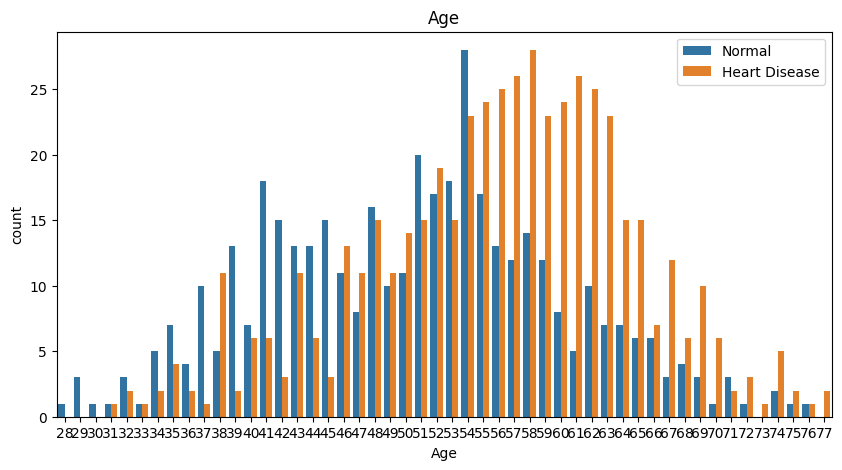

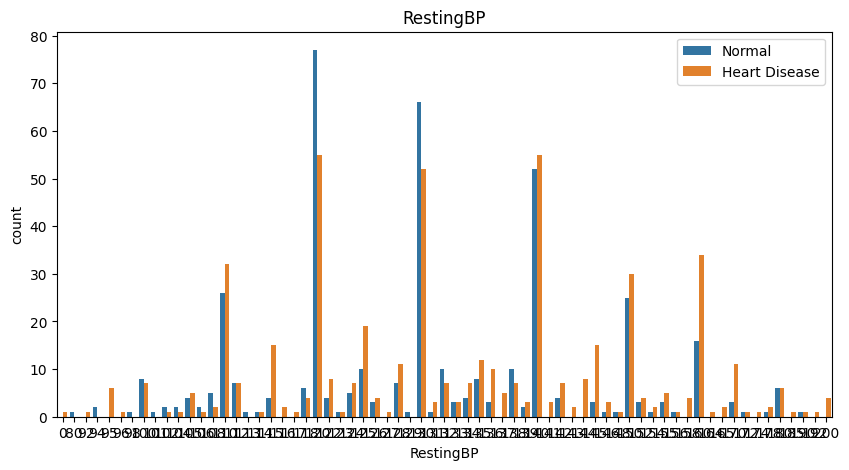

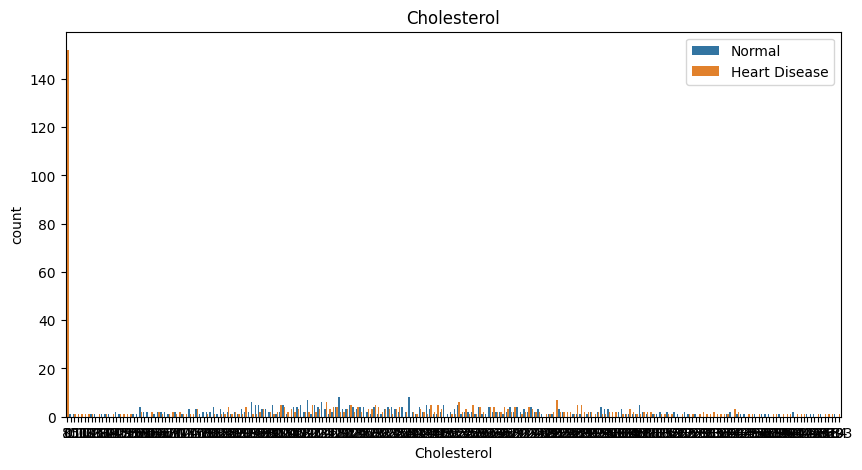

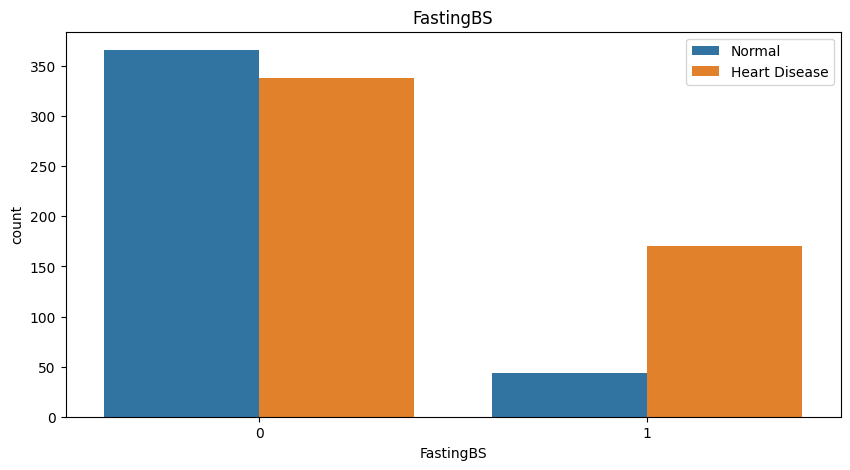

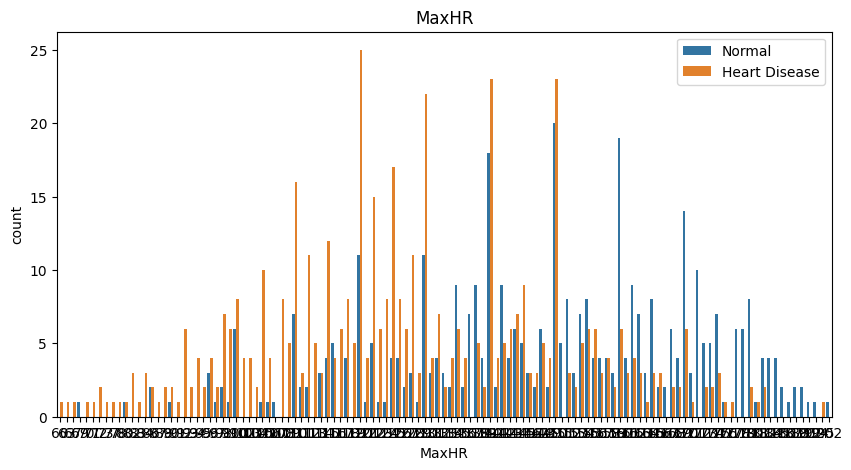

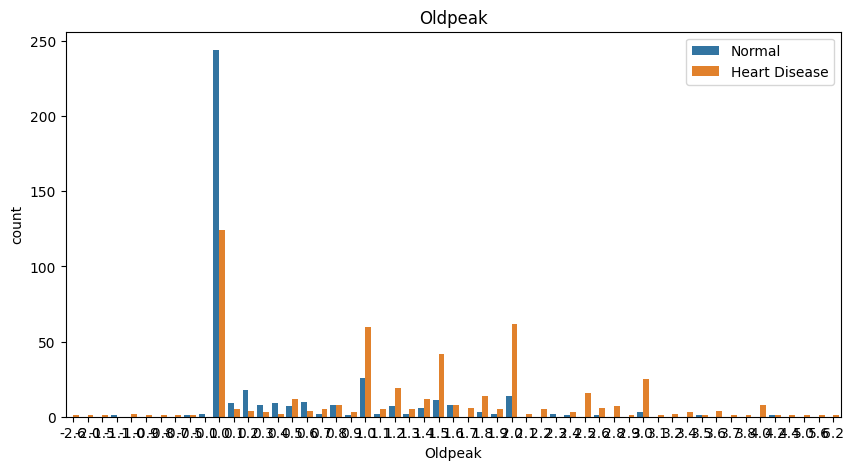

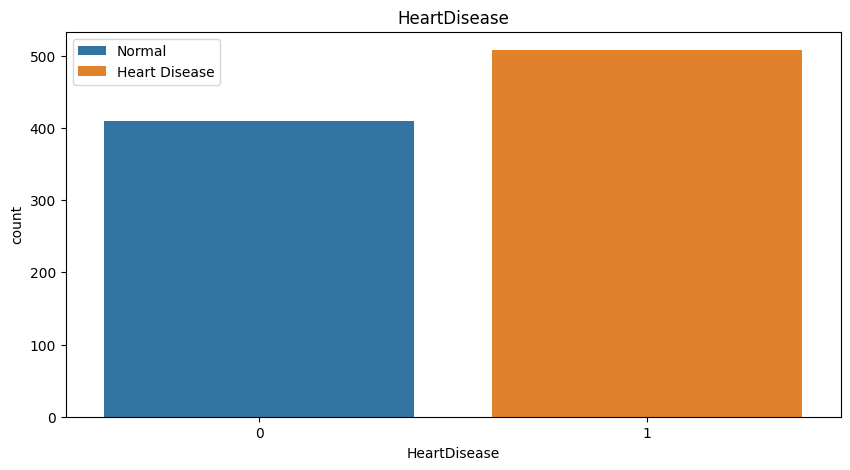

In [24]:
# ploting numerical features with target
for i in Numerical:
    plt.figure(figsize=(10,5))
    sns.countplot(x=i, data=df, hue='HeartDisease')
    plt.legend(['Normal', 'Heart Disease'])
    plt.title(i)
    plt.show()

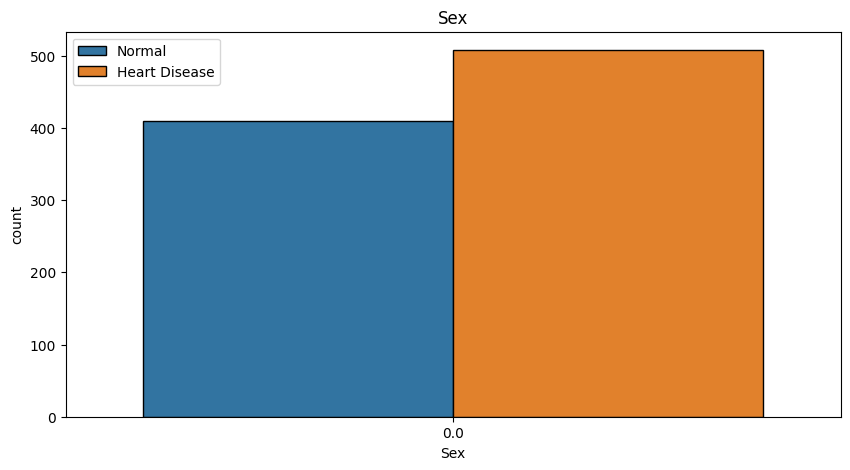

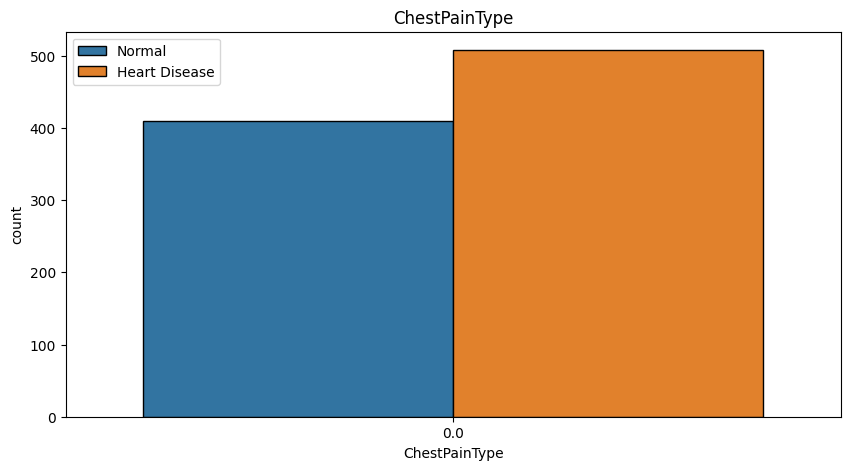

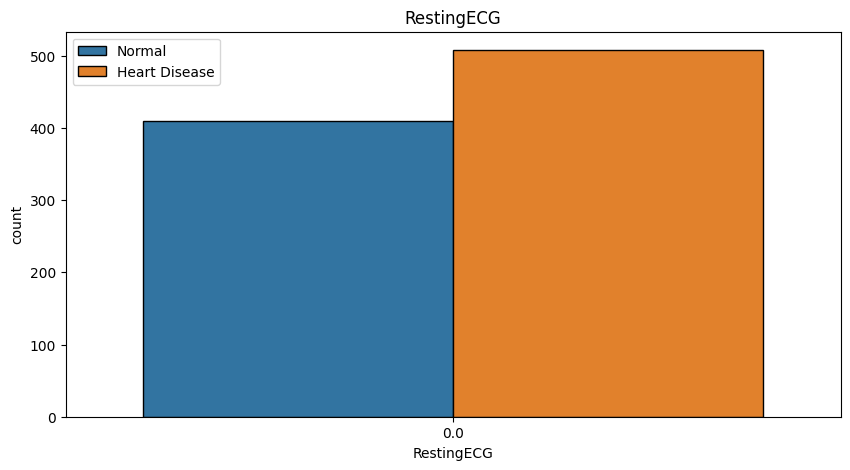

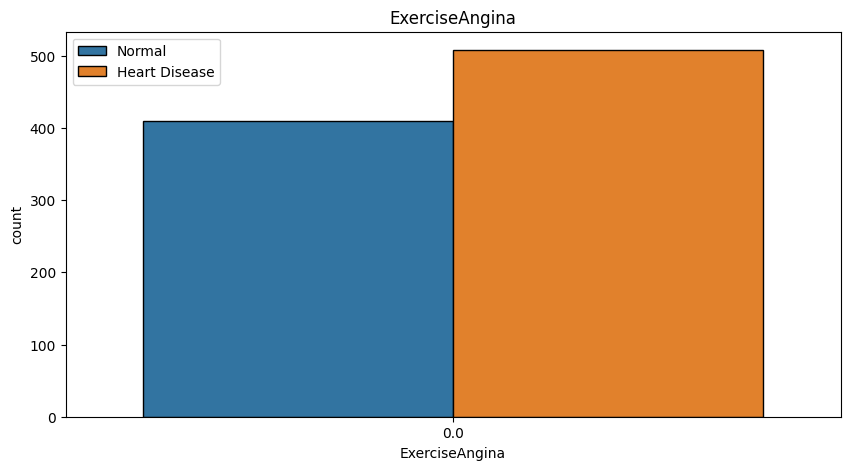

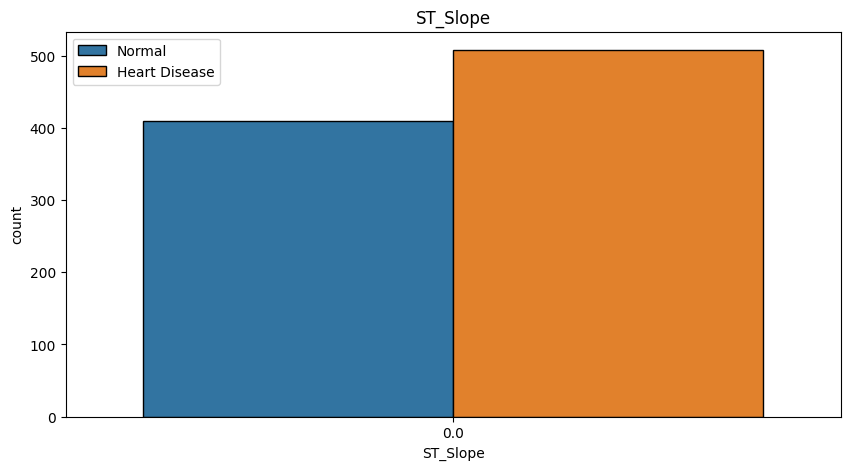

In [25]:
#ploting categorical features with target
for i in Categorical:
    plt.figure(figsize=(10,5))
    sns.countplot(x=i, data=df, hue='HeartDisease', edgecolor='black')
    plt.legend(['Normal', 'Heart Disease'])
    plt.title(i)
    plt.show()

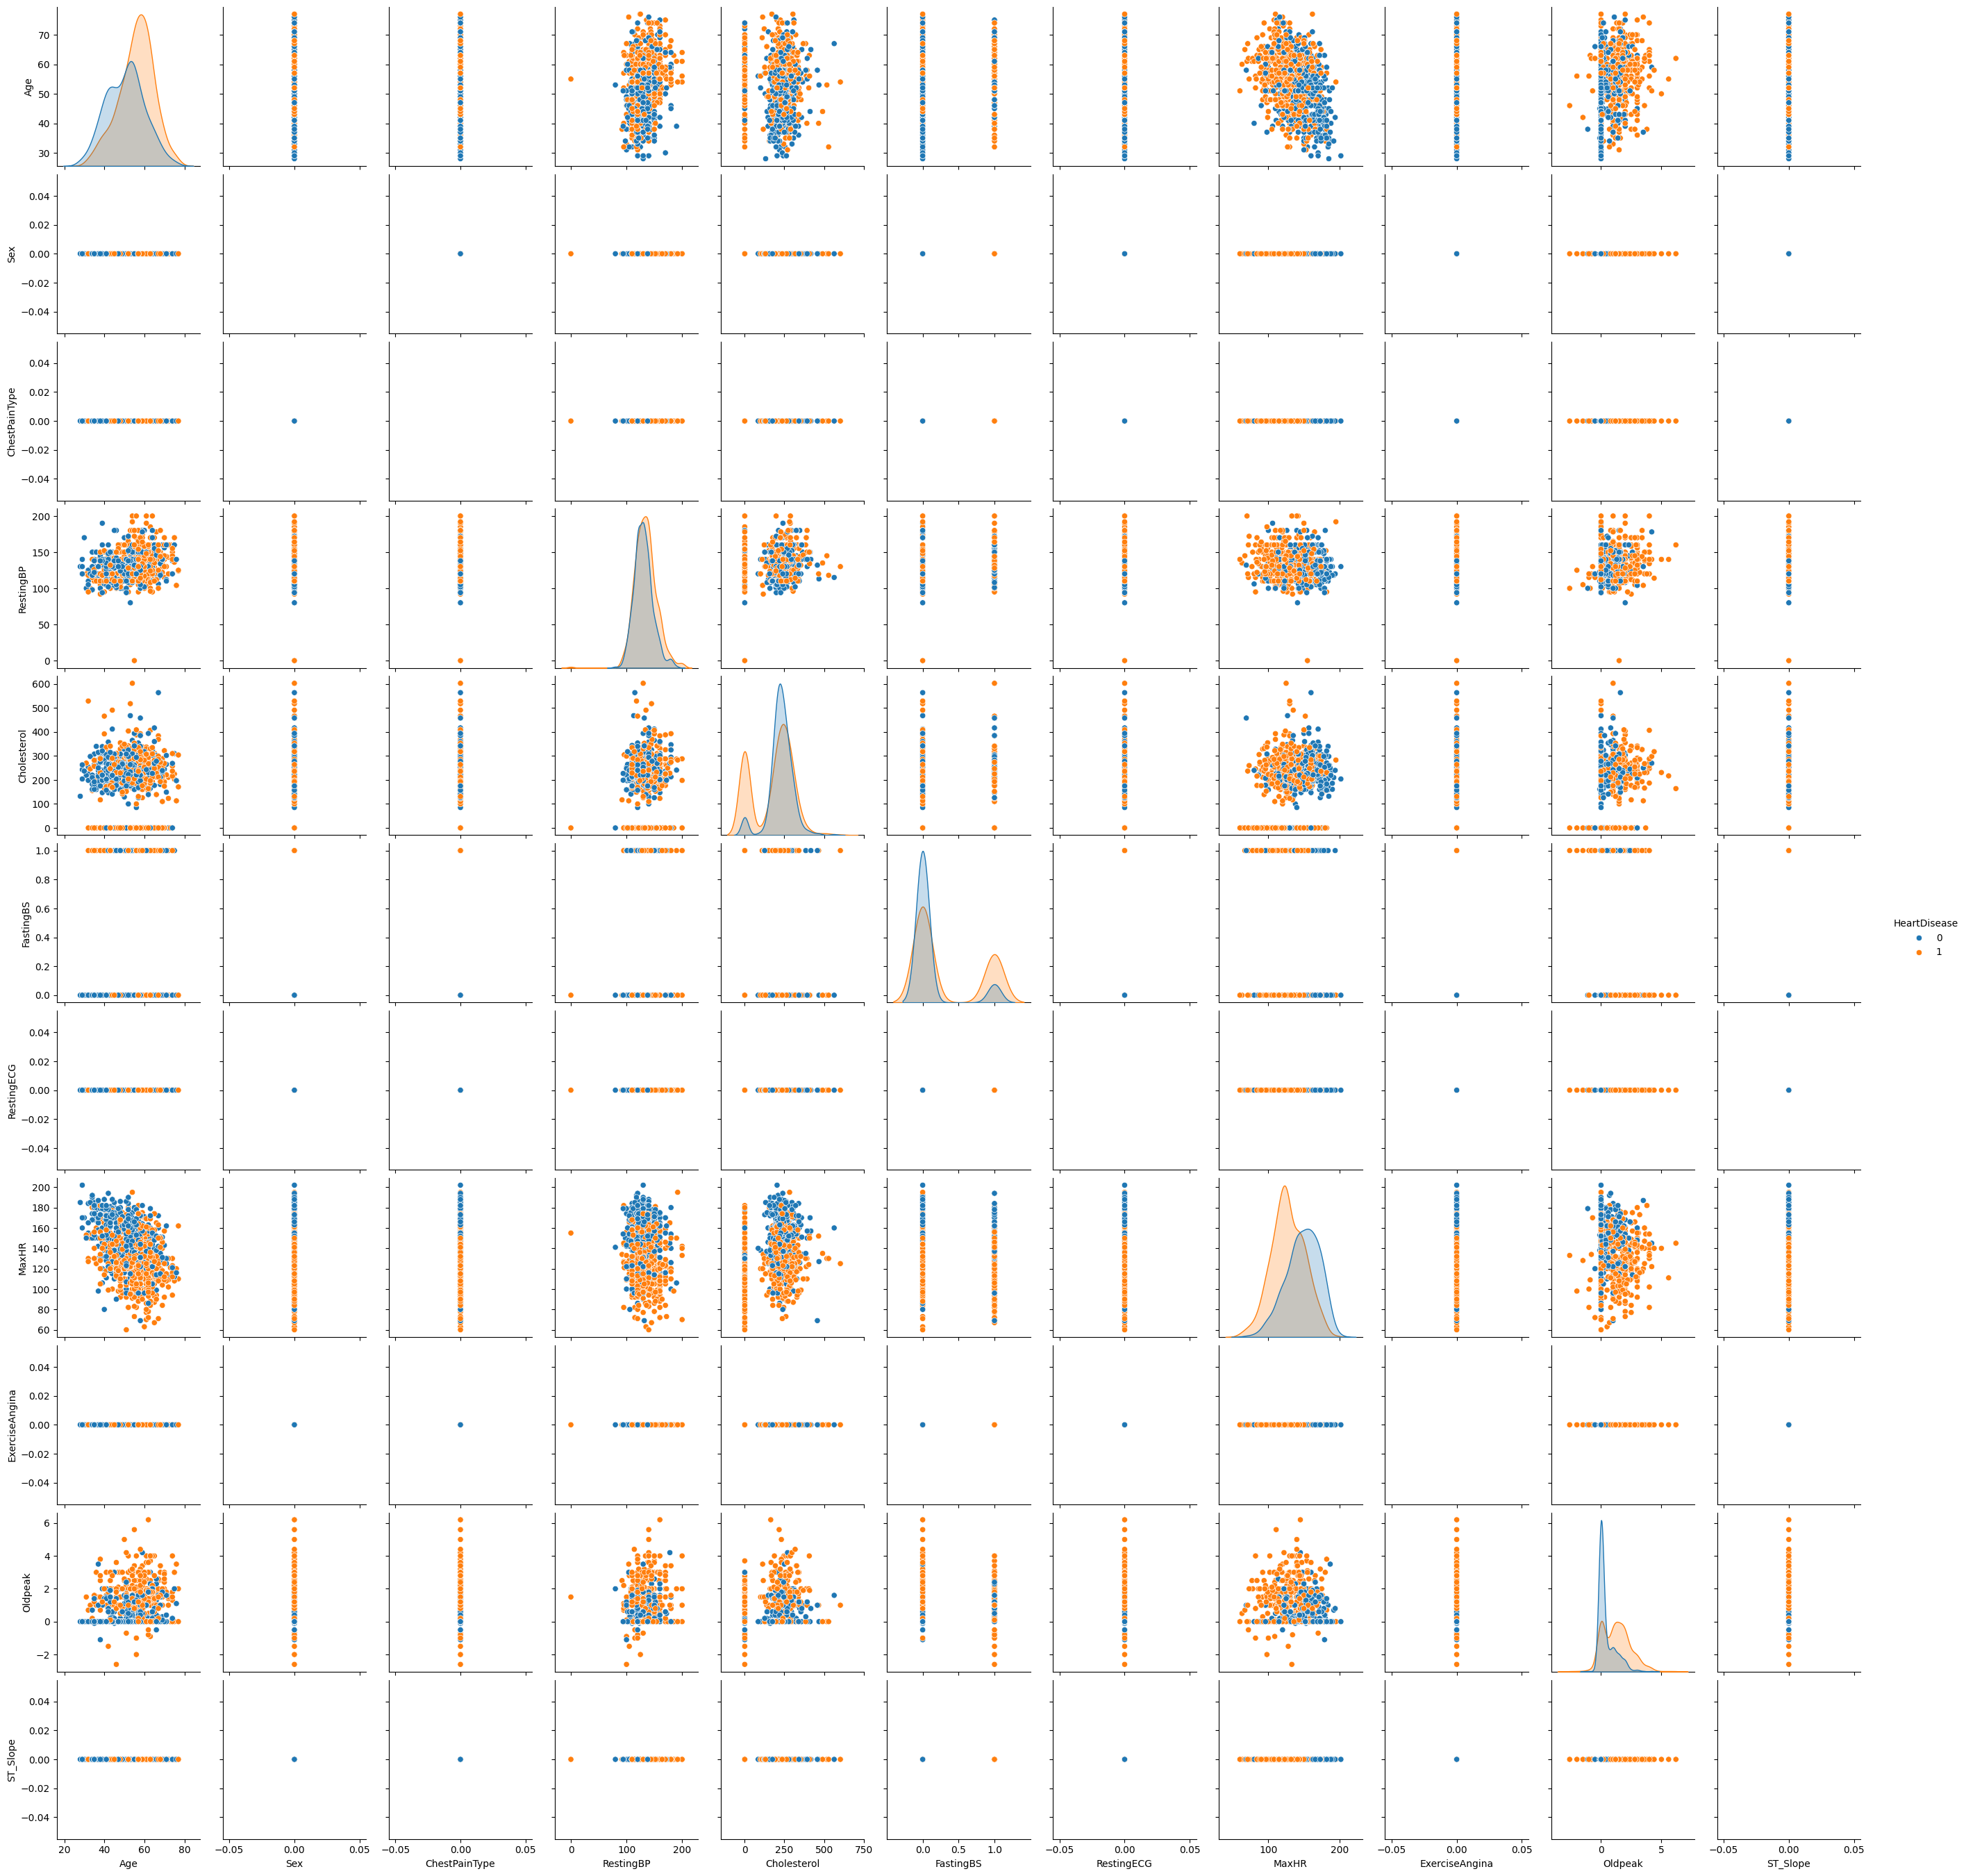

In [26]:
#pairplot using target HeartDisease Column
sns.pairplot(df, hue='HeartDisease')
plt.show()

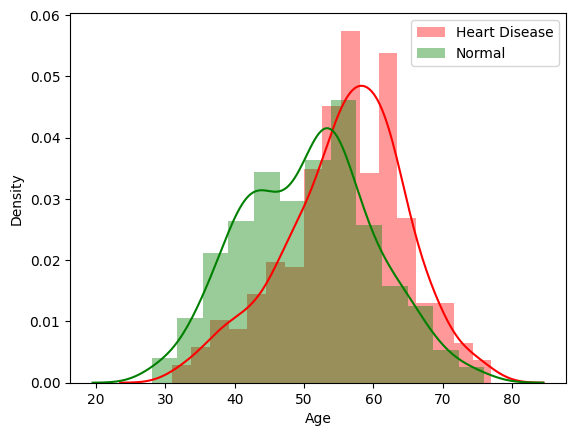

In [27]:
# distribution plot of Age for HeartDisease
sns.distplot(df['Age'][df['HeartDisease'] == 1], kde=True, color='red', label='Heart Disease')
sns.distplot(df['Age'][df['HeartDisease'] == 0], kde=True, color='green', label='Normal')
plt.legend()

## <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:5px 5px;">Data Preprocessing</p>

In [28]:
# select numerical features and encoding it
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# select numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64'])
# apply label encoding
numerical_features = numerical_features.apply(LabelEncoder().fit_transform)
numerical_features.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,12,0,0,41,147,0,0,98,0,10,0,0
1,21,0,0,55,40,0,0,82,0,20,0,1
2,9,0,0,31,141,0,0,25,0,10,0,0
3,20,0,0,39,72,0,0,34,0,25,0,1
4,26,0,0,49,53,0,0,48,0,10,0,0


In [34]:
!pip install xgboost

In [37]:
import pandas as pd

df = pd.read_csv("heart.csv")

# Encode categorical features (this replaces everything)
df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [41]:
X.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


In [42]:
y.head()

,HeartDisease
0,0
1,1
2,0
3,1
4,0


In [43]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:5px 5px;">Model 1: XGboost</p>

In [44]:
# model building xgboost
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=590)
model.fit(X_train, y_train)
# predict
y_pred = model.predict(X_test)
# accuracy
from sklearn.metrics import accuracy_score
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.8695652173913043


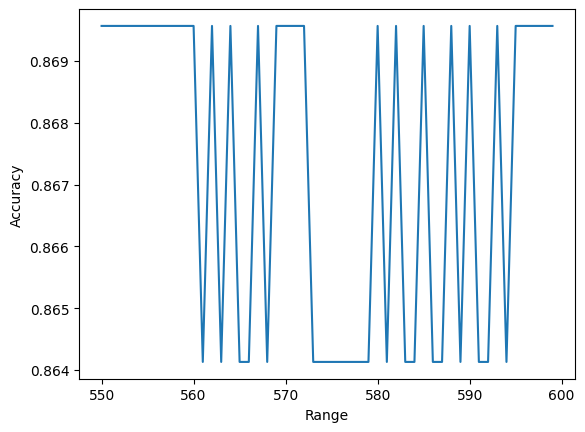

In [45]:
# Finding the best parameters using loop
accuracy = []
for i in range(550, 600):
    model = XGBClassifier(n_estimators=i)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))
# ploting accuracy graph
plt.plot(range(550, 600), accuracy)
plt.ylabel('Accuracy')
plt.xlabel('Range')
plt.show()

In [46]:
# print precetion, recall, f1 score
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85        77
           1       0.90      0.87      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



<Axes: >

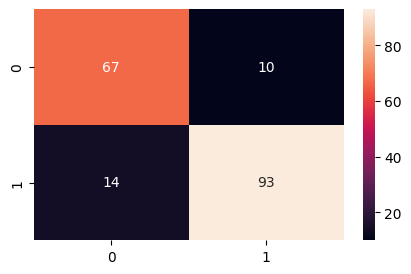

In [47]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,3))
sns.heatmap(cm, annot=True)

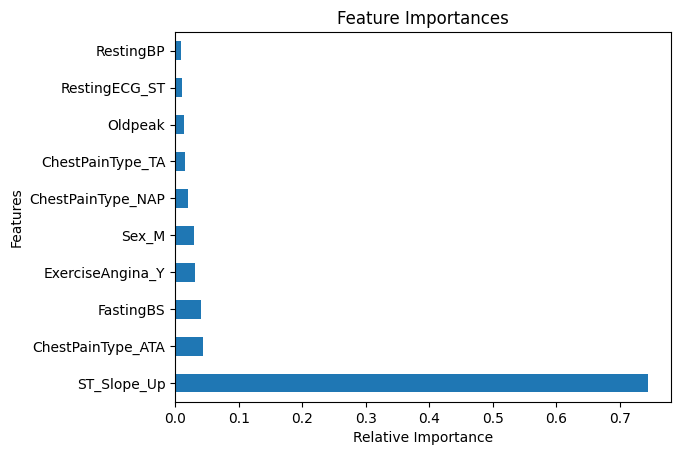

In [48]:
# Feature importance for xgboost
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.title('Feature Importances')
plt.show()

In [51]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


## <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:5px 5px;">Model 2: Catboost</p>

In [52]:
# model building catboost
from catboost import CatBoostClassifier
model2 = CatBoostClassifier(iterations=107)
model2.fit(X_train, y_train)
# predict
y_pred = model2.predict(X_test)
# Print accuracy
from sklearn.metrics import accuracy_score
print('Accuracy:', accuracy_score(y_test, y_pred))
# print classification report
from sklearn.metrics import classification_report
print('Classification report\n',classification_report(y_test, y_pred))

Learning rate set to 0.070088
0:	learn: 0.6629355	total: 48.2ms	remaining: 5.11s
1:	learn: 0.6388671	total: 49.3ms	remaining: 2.59s
2:	learn: 0.6132390	total: 50.4ms	remaining: 1.75s
3:	learn: 0.5919666	total: 51.4ms	remaining: 1.32s
4:	learn: 0.5724378	total: 52.5ms	remaining: 1.07s
5:	learn: 0.5555354	total: 53.5ms	remaining: 901ms
6:	learn: 0.5387059	total: 54.5ms	remaining: 779ms
7:	learn: 0.5232507	total: 55.5ms	remaining: 687ms
8:	learn: 0.5097302	total: 56.6ms	remaining: 616ms
9:	learn: 0.4964953	total: 57.6ms	remaining: 559ms
10:	learn: 0.4847620	total: 58.3ms	remaining: 509ms
11:	learn: 0.4764039	total: 58.5ms	remaining: 463ms
12:	learn: 0.4670946	total: 59.7ms	remaining: 431ms
13:	learn: 0.4575580	total: 60.8ms	remaining: 404ms
14:	learn: 0.4483569	total: 61.8ms	remaining: 379ms
15:	learn: 0.4402713	total: 62.9ms	remaining: 358ms
16:	learn: 0.4343042	total: 64.1ms	remaining: 339ms
17:	learn: 0.4274915	total: 64.5ms	remaining: 319ms
18:	learn: 0.4217301	total: 65.6ms	remaining

Learning rate set to 0.074574
0:	learn: 0.6610671	total: 3.34ms	remaining: 331ms
1:	learn: 0.6356809	total: 5.18ms	remaining: 254ms
2:	learn: 0.6088002	total: 7.14ms	remaining: 231ms
3:	learn: 0.5866130	total: 8.91ms	remaining: 214ms
4:	learn: 0.5663820	total: 10.8ms	remaining: 205ms
5:	learn: 0.5489606	total: 12ms	remaining: 188ms
6:	learn: 0.5316664	total: 13.2ms	remaining: 175ms
7:	learn: 0.5158566	total: 14.4ms	remaining: 165ms
8:	learn: 0.5021126	total: 15.8ms	remaining: 160ms
9:	learn: 0.4886760	total: 17.1ms	remaining: 154ms
10:	learn: 0.4768556	total: 17.8ms	remaining: 144ms
11:	learn: 0.4685837	total: 18.5ms	remaining: 135ms
12:	learn: 0.4592670	total: 19.9ms	remaining: 134ms
13:	learn: 0.4497327	total: 21.9ms	remaining: 134ms
14:	learn: 0.4405272	total: 23.7ms	remaining: 134ms
15:	learn: 0.4324983	total: 25ms	remaining: 131ms
16:	learn: 0.4265802	total: 26.3ms	remaining: 128ms
17:	learn: 0.4199413	total: 26.7ms	remaining: 122ms
18:	learn: 0.4142663	total: 28ms	remaining: 119m

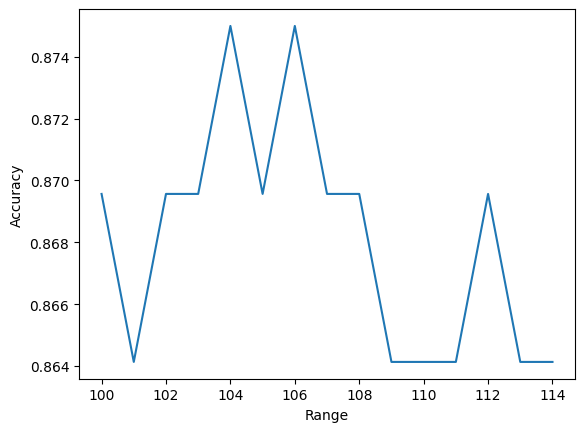

In [53]:
# Simple parameter tuning using loop
accuracy = []
for i in range(100, 115):
    model2 = CatBoostClassifier(iterations=i)
    model2.fit(X_train, y_train)
    y_pred = model2.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))
# ploting accuracy graph
plt.plot(range(100, 115), accuracy)
plt.ylabel('Accuracy')
plt.xlabel('Range')
plt.show()

<Axes: >

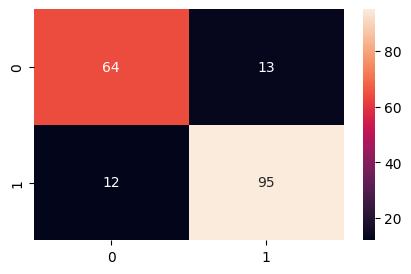

In [54]:
# plot confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,3))
sns.heatmap(cm, annot=True)

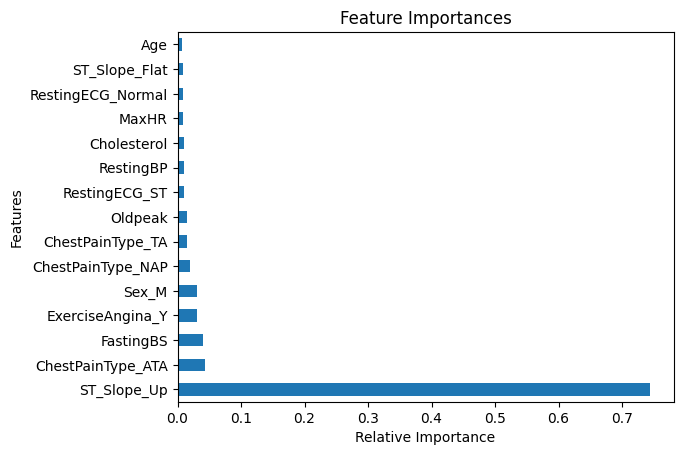

In [55]:
# Feature importance for xgboost
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.title('Feature Importances')
plt.show()

In [56]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [57]:
sample = X_test.iloc[0:1]
print("Input:\n", sample)

pred = model.predict(sample)
print("Prediction:", pred)

Input:
      Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
668   63        140          195          0    179      0.0  False   

     ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
668               True              False             False   

     RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
668               True          False             False          False   

     ST_Slope_Up  
668         True  
Prediction: [0]
